<a href="https://colab.research.google.com/github/drpeppurr/yamcha/blob/main/tutorial/YAMCHA_tutorial_ch12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.special import erf
from matplotlib.ticker import FormatStrFormatter

import xarray as xr

Text(0.5, 0, 'diameter ($\\mu$m)')

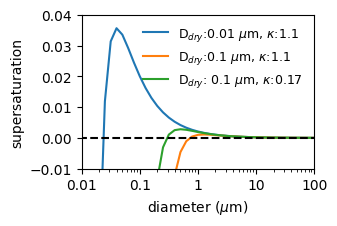

In [3]:
def kohler_seq(Dwet_m,Ddry_m,T,kappa):
    surface_tension_water = 0.072
    Mw = 0.018        # molecular weight of water
    rho_w = 1000.0    # density of water
    A = 4.0*surface_tension_water*Mw/(8.314*T*rho_w)  # Kelvin effect
    Seq = np.exp(A/Dwet_m)*(Dwet_m**3-Ddry_m**3)/(Dwet_m**3-Ddry_m**3*(1.0-kappa))-1.
    return Seq



values_Dwet_um = 10**np.arange(-3,3,0.1)

values_Seq_droplet_Ddry10nm = []
values_Seq_droplet_Ddry100nm = []
values_Seq_droplet_Ddry100nm_loKappa = []
for d in values_Dwet_um:
    Ddry_um = 0.01
    if d<=Ddry_um: seq = np.nan
    else: seq = kohler_seq(d*1e-6,Ddry_um*1e-6,298,1.1)
    values_Seq_droplet_Ddry10nm.append(seq)

    Ddry_um = 0.1
    if d<=Ddry_um: seq = np.nan
    else: seq = kohler_seq(d*1e-6,Ddry_um*1e-6,298,1.1)
    values_Seq_droplet_Ddry100nm.append(seq)

    Ddry_um = 0.1
    if d<=Ddry_um: seq = np.nan
    else: seq = kohler_seq(d*1e-6,Ddry_um*1e-6,298,0.17)
    values_Seq_droplet_Ddry100nm_loKappa.append(seq)



fig, axs = plt.subplots(nrows=1,ncols=1,figsize=(3,2))
axs.plot(values_Dwet_um,values_Seq_droplet_Ddry10nm,label=r'D$_{dry}$:0.01 $\mu$m, $\kappa$:1.1')
axs.plot(values_Dwet_um,values_Seq_droplet_Ddry100nm,label=r'D$_{dry}$:0.1 $\mu$m, $\kappa$:1.1')
axs.plot(values_Dwet_um,values_Seq_droplet_Ddry100nm_loKappa,label=r'D$_{dry}$: 0.1 $\mu$m, $\kappa$:0.17')
# axs.plot(values_Dwet_um,values_Seq_droplet_Ddry1000nm)
axs.plot(values_Dwet_um,values_Dwet_um*0.,'k--')
axs.set_xscale('log')
axs.legend(frameon=False,fontsize=9)
axs.set_ylim([-0.01,0.04])
axs.set_xlim([0.01, 100])
axs.set_xticks([0.01,0.1,1,10,100], labels=[0.01,0.1,1,10,100])
axs.set_ylabel('supersaturation')
axs.set_xlabel(r'diameter ($\mu$m)')

In [4]:
# --- saturation vapor pressure
def esat(T):
    Tc = T-273.15
    return 611.2*np.exp(17.67*Tc/(Tc+243.5))

# --- saturation vapor concentration (kg/kg)
def qsat(T,p):
    es = esat(T)
    return 0.622*es/(p-es)

def rho_air(T,p,qv):
    Rd = 287.05  # R/MW_air
    return p/(Rd*T*(1.0+0.61*qv))

def mean_free_path_air(T,p):
    return 6.6e-8*(101325.0/p)*(T/293.15)

def diffusivity_water_vapor(T,p):
    return 2.11e-5*(T/273.15)**1.94*(101325.0/p)

def thermal_conductivity_air(T):
    return 0.0241*(T/273.15)**1.5*(273.15+194.0)/(T+194.0)

# --- Fuchs-Sutugin correction. important for small particles
#     alpha: mass or thermal accommodation coefficient
def fuchs_sutugin(Kn,alpha):
    return (1.+Kn)/(1.+(4./(3.*alpha)+0.377)*Kn+4.*Kn**2/(3.*alpha))

def condensation_G(T,p,D_m):
    rho_w = 1000.
    Rv = 461.5  # R/Mw
    Lv = 2.5e6  # latent heat for liquid wter condensation
    # --- water vapor diffusivity m2/s
    Dv = diffusivity_water_vapor(T,p)
    # --- thermal conductivity W/m/K
    Ka = thermal_conductivity_air(T)
    # --- saturation vapor pressure
    es = esat(T)
    # --- mean free path
    L = mean_free_path_air(T,p)
    # --- Knudsen number. small particles are in transition regime
    Kn = 2.0*L/D_m
    # --- mass or thermal accommodation coefficient. both set to 1 for now
    alpha = 0.1
    Fd = fuchs_sutugin(Kn,alpha)
    Fk = fuchs_sutugin(Kn,alpha)
    # --- now do transition regime correction which matters for small particles
    Dv_eff = Dv*Fd
    Ka_eff = Ka*Fk
    return 1.0/(rho_w*Rv*T/(Dv_eff*es) + rho_w*Lv*(Lv/(Rv*T)-1.0)/(Ka_eff*T))



def parcel_rhs(t,y,D_dry_um,init_N,w,kappa):
    cp = 1004.0    # specific heat capacity of air
    Lv = 2.5e6
    rho_w = 1000.
    Dwet_um,qv,T,p,z = y[:-4],y[-4],y[-3],y[-2],y[-1]
    # --- need this bit otherwise may fuck things up when shrinking
    too_small = Dwet_um <= D_dry_um
    Dwet_um[too_small] = D_dry_um[too_small] *(1. + 1.e-12)
    # --- ambient supersaturation
    qv = max(qv, 1e-12)
    S = qv/qsat(T,p) - 1.0
    # --- droplet equilibrium
    Seq = kohler_seq(Dwet_um*1e-6,D_dry_um*1e-6,T,kappa)
    # --- dD/dt
    dD_dt = 4.*condensation_G(T,p,Dwet_um*1e-6)*(S-Seq)/(Dwet_um*1e-6)
    # --- dm/dt condensation/evaporation rate
    dm_dt = 0.5*np.pi*rho_w*(Dwet_um*1e-6)**2*dD_dt
    # --- dqv/dt water vapor tendency
    dqv_dt = -np.sum(init_N*dm_dt)/rho_air(T,p,qv)
    # --- dT/dt temperature tendency
    # dT_dt = - (Lv/cp)*dqv_dt
    dT_dt = -(9.81/cp)*w - (Lv/cp)*dqv_dt
    # --- pressure and height
    dp_dt = -rho_air(T,p,qv)*9.81*w
    dz_dt = w
    return np.hstack((dD_dt*1e6,dqv_dt,dT_dt,dp_dt,dz_dt))


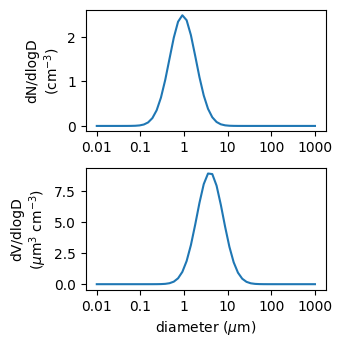

In [16]:
# --- this is not dN/dlogDp, but rather dN/Dp, so the unit is a bit counter intuitive
#     but integrate this over a Dp range should get N
def lognormal_dist_dN_dDp(in_Dp, in_Dp_mean, in_sigma, in_N0):
    return in_N0/np.log(in_sigma)/in_Dp/np.sqrt(2.*np.pi) * np.exp(-0.5*(np.log(in_Dp/in_Dp_mean)**2.)/np.log(in_sigma)/np.log(in_sigma))

# --- integrate dN/dDp in certain ranges
def integ_dN_dDp_range(in_dN_dDp, in_Dp, in_Dp_lower, in_Dp_upper):
    Dp_lower_ind = abs(Dp_um-in_Dp_lower).argmin()
    Dp_upper_ind = abs(Dp_um-in_Dp_upper).argmin()
    return cumulative_trapezoid(in_dN_dDp[Dp_lower_ind:Dp_upper_ind], in_Dp[Dp_lower_ind:Dp_upper_ind])[-1]

# --- calcualte bin bounds from bin centers
def get_bin_bounds(in_Dp_um):
    out_Dp_bounds_um = np.zeros(1+len(in_Dp_um))
    for ibin in range(len(in_Dp_um)):
        if ibin==0:
            out_Dp_bounds_um[1] = 0.5*(in_Dp_um[ibin]+in_Dp_um[ibin+1])
            out_Dp_bounds_um[0] = in_Dp_um[ibin]-(out_Dp_bounds_um[1]-in_Dp_um[ibin])
        elif ibin==-1+len(in_Dp_um):
            out_Dp_bounds_um[ibin] = 0.5*(in_Dp_um[ibin]+in_Dp_um[ibin-1])
            out_Dp_bounds_um[ibin+1] = in_Dp_um[ibin]+(in_Dp_um[ibin]-out_Dp_bounds_um[ibin])
        else:
            out_Dp_bounds_um[ibin] = 0.5*(in_Dp_um[ibin]+in_Dp_um[ibin-1])
    return out_Dp_bounds_um



# --- set aerosol/droplet bins: center and bounds
N_bins = 51
D_um = 10**np.linspace(-2, 3, N_bins+1)
D_bounds_um = get_bin_bounds(D_um)

rho_aerosol_kg_m3 = 1800.
init_N_cm3 = lognormal_dist_dN_dDp(D_um, in_Dp_mean=1.5, in_sigma=2., in_N0=0.5)
init_dN_dlogDp_cm3 = init_N_cm3/np.diff(np.log10(D_bounds_um))
init_dV_dlogDp_um3_cm3 = init_N_cm3*(np.pi/6.)*(D_um**3.)/np.diff(np.log10(D_bounds_um))


fig, axs = plt.subplots(2, 1, figsize=(3, 3.5))
axs[0].plot(D_um,init_dN_dlogDp_cm3)
axs[1].plot(D_um,init_dV_dlogDp_um3_cm3)
axs[0].set_ylabel('dN/dlogD\n(cm$^{-3}$)')
axs[1].set_ylabel('dV/dlogD\n($\\mu$m$^3$ cm$^{-3}$)')
axs[1].set_xlabel('diameter ($\\mu$m)')

for ax in axs:
    ax.set_xscale('log')
    ax.set_xticks([0.01,0.1,1,10,100,1000], labels=[0.01,0.1,1,10,100,1000])

plt.subplots_adjust(top=0.95, bottom=0.15, left=0.15, right=0.95, hspace=0.3, wspace=0.2)

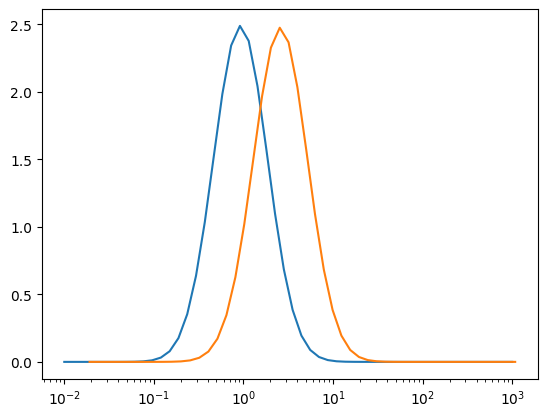

In [7]:
# --- initial temperature, pressure, and specific humidity
T0 = 280.
p0 = 90000.
qv0 = 0.95 * qsat(T0,p0)
# qv0 = 1.001 * qsat(T0,p0)

# --- set time
dt = 10
time_s = np.arange(0,300,dt)

# --- call the solver
sol = solve_ivp(parcel_rhs,
                t_span=(0, time_s[-1]),
                y0=np.concatenate((D_um,[qv0,T0,p0,0])),
                t_eval=time_s,
                args=(D_um, init_N_cm3, 0, 1.1),
                method="BDF",rtol=1e-6,atol=1e-10)

# --- get the new sizes!
D_wet_um = sol.y[:-4,:]

# --- liquid water content
LWC_g_m3 = [np.sum(init_N_cm3*(np.pi/6.)*(D_wet_um[:,i]**3.)) * 1e-6 for i in range(len(time_s))]

plt.plot(D_um,init_N_cm3/np.diff(np.log10(get_bin_bounds(D_um))),label='initial')
plt.plot(D_wet_um[:,-1],init_N_cm3/np.diff(np.log10(get_bin_bounds(D_wet_um[:,-1]))),label='final')
plt.xscale('log')

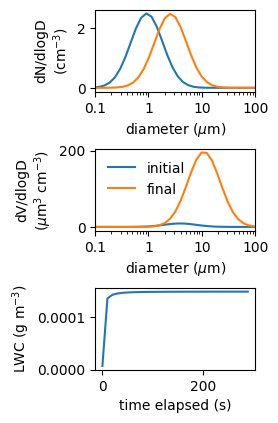

In [14]:
fig, axs = plt.subplots(3, 1, figsize=(2, 4.5))
axs[0].plot(D_um,init_dN_dlogDp_cm3,label='initial')
axs[1].plot(D_um,init_dV_dlogDp_um3_cm3,label='initial')
axs[0].set_ylabel('dN/dlogD\n(cm$^{-3}$)')
axs[1].set_ylabel('dV/dlogD\n($\\mu$m$^3$ cm$^{-3}$)')

axs[0].plot(D_wet_um[:,-1],init_N_cm3/np.diff(np.log10(get_bin_bounds(D_wet_um[:,-1]))),label='final')
axs[1].plot(D_wet_um[:,-1],init_N_cm3*(np.pi/6.)*(D_wet_um[:,-1]**3.)/np.diff(np.log10(get_bin_bounds(D_wet_um[:,-1]))),label='final')
axs[1].legend(frameon=False)

axs[2].plot(time_s, LWC_g_m3)
axs[2].set_ylabel(r'LWC (g m$^{-3}$)')
axs[2].set_xlabel(r'time elapsed (s)')

for i in [0,1]:
    axs[i].set_xlim([0.1, 100])
    axs[i].set_xscale('log')
    axs[i].set_xticks([0.1,1,10,100], labels=[0.1,1,10,100])
    axs[i].set_xlabel(r'diameter ($\mu$m)')

plt.subplots_adjust(top=0.95, bottom=0.15, left=0.15, right=0.95, hspace=0.7, wspace=0.2)

Text(0, 0.5, 'mass concentration (g m$^{-3}$)')

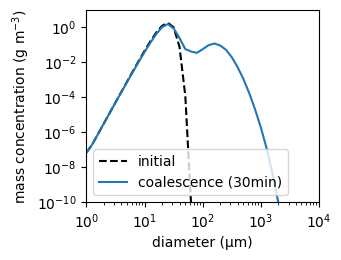

In [15]:
# =============================================================================
# Terminal velocity of droplets.
# Table 3 for sea level terminal velocity at 1atm and 20degC, from Beard (1977)
# Note: can't make sense of the polynomial fitting in Table 4...
# Table 2 is a correction for other conditions... skip it for now
# -----------------------------------------------------------------------------
# The formulation used to calculate gravatational setting (Stokes) works for
# smaller droplets, but for bigger ones, will create unrealistically fast
# terminal velocity. Thus this approach...
# =============================================================================
def TerminalVelocity_Beard1977(D):
    Beard1977_D_um = np.array([1.0,1.5,2.0,3.0,4.0,6.0,8.0,10.0,15.0,20.0,30.0,40.0,
                               60.0,80.0,100.0,150.0,200.0,300.0,400.0,600.0,800.0,
                               1000.0,1500.0,2000.0,3000.0,4000.0,5000.0,6000.0])
    Beard1977_v0_cm_s = np.array([3.48e-3,7.47e-3,1.294e-2,2.84e-2,4.98e-2,1.105e-1,
                                  1.951e-1,0.304,0.670,1.201,2.68,4.70,10.18,17.08,
                                  25.0,46.7,69.4,114.7,158.8,244.0,326.0,402.0,542.0,
                                  653.0,808.0, 885.0,912.0,914.0])
    logDlut = np.log(Beard1977_D_um)
    logVlut = np.log(Beard1977_v0_cm_s/100.0)   # cm/s -> m/s
    D_um = np.asarray(D,dtype=float)*1e6
    D_um = np.clip(D_um, Beard1977_D_um[0], Beard1977_D_um[-1])
    return np.exp(np.interp(np.log(D_um),logDlut,logVlut))


# ===========================================================
# Collection efficiency from Hall (1980). Di and Dj in meters
# ===========================================================
def LUT_Hall1980_CollectionEfficiency(Di, Dj):
    from scipy.interpolate import RegularGridInterpolator
    Hall1980_R = np.array([10,20,30,40,50,60,70,100,150,200,300],dtype=float)
    Hall1980_ratio = np.array([0., 0.05,0.10,0.15,0.20,0.25,0.30,0.35,0.40,0.45,0.50,
                              0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90,0.95,1.00])
    Hall1980_E = np.array([[0., 0.0001,0.0001,0.0001,0.014,0.017,0.019,0.022,0.027,0.030,0.033,
                            0.035,0.037,0.038,0.038,0.037,0.036,0.035,0.032,0.029,0.027],
                          [0., 0.0001,0.0001,0.005,0.016,0.022,0.030,0.043,0.052,0.064,0.072,
                            0.079,0.082,0.080,0.076,0.067,0.057,0.048,0.040,0.033,0.027],
                          [0., 0.0001,0.002,0.020,0.040,0.085,0.170,0.270,0.4,0.5,0.550,
                            0.580,0.590,0.580,0.540,0.510,0.490,0.470,0.450,0.470,0.520],
                          [0., 0.001,0.070,0.280,0.5,0.620,0.680,0.740,0.780,0.8,0.8,
                            0.8,0.780,0.770,0.760,0.770,0.770,0.780,0.790,0.950,1.400],
                          [0., 0.005,0.4,0.6,0.7,0.780,0.830,0.860,0.880,0.9,0.9,
                            0.9,0.9,0.890,0.880,0.880,0.890,0.920,1.010,1.300,2.300],
                          [0., 0.050,0.430,0.640,0.770,0.840,0.870,0.890,0.9,0.91,0.91,
                            0.91,0.91,0.91,0.920,0.930,0.950,1.,1.030,1.700,3.000],
                          [0., 0.2,0.580,0.750,0.840,0.880,0.9,0.920,0.940,0.950,0.950,
                            0.950,0.950,0.950,0.950,0.970,1.,1.020,1.040,2.300,4.000],
                          [0., 0.5,0.790,0.91,0.950,0.950,1.,1.,1.,1.,1.,
                            1.,1.,1.,1.,1.,1.,1.,1.,1.,1.],
                          [0., 0.770,0.930,0.970,0.970,1.,1.,1.,1.,1.,1.,
                            1.,1.,1.,1.,1.,1.,1.,1.,1.,1.],
                          [0., 0.870,0.960,0.980,1.,1.,1.,1.,1.,1.,1.,
                            1.,1.,1.,1.,1.,1.,1.,1.,1.,1.],
                          [0., 0.970,1.,1.,1.,1.,1.,1.,1.,1.,1.,
                            1.,1.,1.,1.,1.,1.,1.,1.,1.,1.]],dtype=float)
    # --- now build interpolator
    Hall1980_interp = RegularGridInterpolator((Hall1980_R, Hall1980_ratio), Hall1980_E,
                                              bounds_error=False,fill_value=None)
    Ri = 0.5*Di*1e6
    Rj = 0.5*Dj*1e6
    Rbig = max(Ri, Rj)
    Rsmall = min(Ri, Rj)
    rr = Rsmall/Rbig
    Rbig = np.clip(Rbig, Hall1980_R[0], Hall1980_R[-1])
    rr = np.clip(rr, Hall1980_ratio[0], Hall1980_ratio[-1])
    return float(Hall1980_interp((Rbig, rr)))


# =======================================================================================
# Coalescene solver. Uses an Eulerian solver. dt shouldn't be small anyway (e.g. <10s)
# Input Dwet should be in meters
# IMPORTANT: 1. This approach uses fixed bins, rather than moving-bin (like condensation)
#            2. Upper limit of the size range needs to be sufficiently big. Otherwise
#               the results will be weird..
# =======================================================================================
def collision_coalescence(Dwet_um,N_cm3,dt):
    Dwet = Dwet_um * 1e-6  # convert from um to m
    N = N_cm3 * 1000000.   # convert from #/cm3 to #/m3
    rho_w = 1000.
    nbins = len(Dwet)
    m = (np.pi*rho_w/6.0)*Dwet**3
    dN = np.zeros(nbins)
    # --- terminal velocity using Beard 1977 lookup table
    #     temperature/pressure correction skipped for now
    vt = TerminalVelocity_Beard1977(Dwet)
    Kmax,imax,jmax = -1.,0,0
    for i in range(nbins):
        for j in range(i,nbins):
            # --- terminal velocities
            vti, vtj = vt[i], vt[j]
            # --- collection efficiency. Use Hall (1980) lookup table
            Eij = LUT_Hall1980_CollectionEfficiency(Dwet[i], Dwet[j])
            # --- coalescence kernel
            K = Eij*(np.pi/4.0)*(Dwet[i]+Dwet[j])**2*np.abs(vti-vtj)
            # --- N_collision: number of collisions during the time step
            #     a single timestep can't consume more droplets than exist in the bin(s)
            #     thus the 'min' constraints...
            if i==j:
                N_collision = 0.5*K*N[i]*N[j]*dt
                N_collision = min(N_collision, N[i]/2.0)
            else:
                N_collision = K*N[i]*N[j]*dt
                N_collision = min(N_collision, N[i], N[j])
            # --- skip this pair if N_collision <= 0
            if N_collision<=0.0: continue
            # --- mnew: mass of the newly formed droplet
            mnew = m[i] + m[j]
            # --- bin_ind_new: index of the newly formed droplet
            bin_ind_new = np.searchsorted(m,mnew)
            dN[i] -= N_collision
            dN[j] -= N_collision
            # --- unlikely but just in case...
            if bin_ind_new==0: dN[0] += N_collision
            # --- if the 'new' bin is bigger than the biggest bin, dump into the biggest bin...
            elif bin_ind_new>=nbins: dN[-1] += N_collision
            # --- distribute the new bin into two neighboring bins
            else:
                k1, k2 = bin_ind_new-1, bin_ind_new
                f = (mnew-m[k1])/(m[k2]-m[k1])
                dN[k1] += N_collision*(1.0-f)
                dN[k2] += N_collision*f
            if K>Kmax: Kmax,imax,jmax = K,i,j
    N_new = np.maximum(N+dN,0.0)
    return N_new/1000000.   # convert from #/m3 to #/cm3




# ============
# Bott test!!!
# ============
LWC = 1e-3      # kg m^-3
rbar = 10e-6    # m
xbar = (4.0*np.pi/3.0)*1000.*rbar**3

Bott_Dwet_um = 10**np.linspace(0,4,41)
Bott_dlnd = np.log((Bott_Dwet_um[1]/2.0)/(Bott_Dwet_um[0]/2.0))
m = 1000.*(np.pi/6.0)*(Bott_Dwet_um*1e-6)**3

# -- dist func used in Bott
n_mass = (LWC/xbar**2)*np.exp(-m/xbar)
dm = np.empty_like(m)
dm[1:-1] = 0.5*(m[2:] - m[:-2])
dm[0] = m[1] - m[0]
dm[-1] = m[-1] - m[-2]
Bott_N = n_mass*dm



t_end = 1800
dt = 20
for i in range(int(t_end/dt)):
    if i==0: init_N_coalescane,init_M_coalescane = Bott_N,Bott_N*m
    else: init_N_coalescane,init_M_coalescane = N_coalescane*1e+6,N_coalescane*1e+6*m
    N_coalescane = collision_coalescence(Bott_Dwet_um,init_N_coalescane*1e-6,dt)
    # print(i)



fig, axs = plt.subplots(nrows=1,ncols=1,figsize=(3,2.5))
axs.plot(Bott_Dwet_um, Bott_N*m*1000/Bott_dlnd, 'k--', label='initial')
axs.plot(Bott_Dwet_um, 1e+6*N_coalescane*m*1000/Bott_dlnd, '-', label='coalescence (30min)')
axs.legend()
axs.set_xscale('log')
axs.set_yscale('log')
axs.set_ylim([1e-10, 1e+1])
axs.set_xlim([1, 10000])
axs.set_xlabel('diameter (μm)')
axs.set_ylabel('mass concentration (g m$^{-3}$)')